In [1]:
# Cell 1: Imports & Paths

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Paths
ORDERS_PATH = Path("../data/processed/orders_clean.csv")
SHIPMENTS_PATH = Path("../data/processed/shipments_clean.csv")
INVENTORY_PATH = Path("../data/processed/inventory_clean.csv")
SUPPLIERS_PATH = Path("../data/processed/suppliers_clean.csv")

OUTPUT_DIR = Path("../visuals/charts_from_notebook")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Paths loaded successfully.")


Paths loaded successfully.


In [2]:
# Cell 2: Load datasets

orders_df = pd.read_csv(ORDERS_PATH)
shipments_df = pd.read_csv(SHIPMENTS_PATH)
inventory_df = pd.read_csv(INVENTORY_PATH)
suppliers_df = pd.read_csv(SUPPLIERS_PATH)

# Parse dates where needed
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])
shipments_df["shipment_date"] = pd.to_datetime(shipments_df["shipment_date"])
shipments_df["actual_delivery_date"] = pd.to_datetime(shipments_df["actual_delivery_date"])

print("Orders:", orders_df.shape)
print("Shipments:", shipments_df.shape)
print("Inventory:", inventory_df.shape)
print("Suppliers:", suppliers_df.shape)


Orders: (30000, 18)
Shipments: (24000, 18)
Inventory: (15000, 11)
Suppliers: (50, 10)


In [3]:
# Cell 3: High-level KPI metrics

total_orders = len(orders_df)
total_revenue = orders_df["order_value"].sum()

avg_shipping_delay = orders_df["shipping_delay_days"].mean()
delivery_otd = shipments_df["delivered_on_time_flag"].mean() * 100
shipment_delay_pct = shipments_df["is_delayed"].mean() * 100

inventory_low_pct = (
    inventory_df["inventory_status"].isin(["Critical", "Out-of-Stock"]).mean() * 100
)

print(f"Total Orders: {total_orders:,}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Avg Shipping Delay: {avg_shipping_delay:.2f} days")
print(f"On-Time Delivery Rate (OTD): {delivery_otd:.2f}%")
print(f"Shipment Delay %: {shipment_delay_pct:.2f}%")
print(f"Inventory at Risk (Critical/Stockout): {inventory_low_pct:.2f}%")


Total Orders: 30,000
Total Revenue: $58,131,313.02
Avg Shipping Delay: 0.50 days
On-Time Delivery Rate (OTD): 38.07%
Shipment Delay %: 51.99%
Inventory at Risk (Critical/Stockout): 7.65%


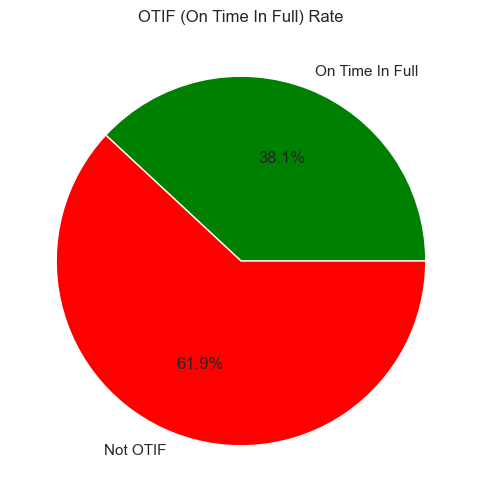

Saved: ..\visuals\charts_from_notebook\otif_rate.png


In [4]:
# Cell 4: OTIF calculation

otif = shipments_df["delivered_on_time_flag"].mean() * 100

plt.figure(figsize=(6, 6))
plt.pie(
    [otif, 100 - otif],
    labels=["On Time In Full", "Not OTIF"],
    autopct="%1.1f%%",
    colors=["green", "red"]
)
plt.title("OTIF (On Time In Full) Rate")

file_path = OUTPUT_DIR / "otif_rate.png"
plt.savefig(file_path, dpi=300)
plt.show()

print(f"Saved: {file_path}")


C:\Users\Charan\AppData\Local\Temp\ipykernel_23076\452992576.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


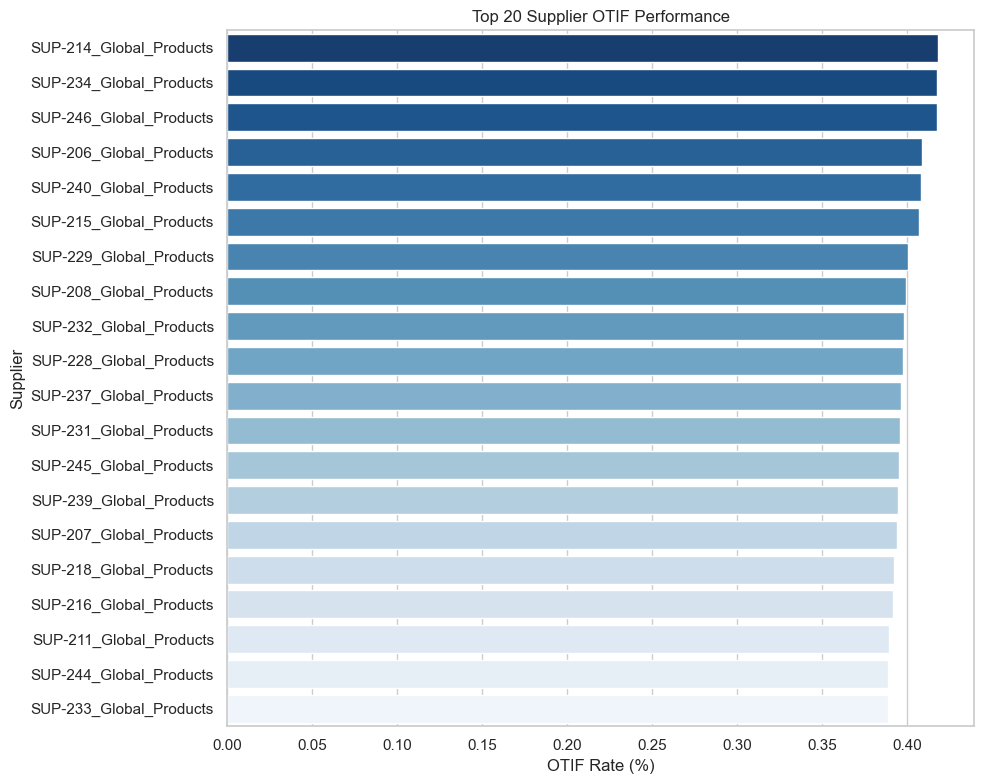

Saved: ..\visuals\charts_from_notebook\supplier_otif_top20.png


,supplier_id,otif_rate,supplier_name
14,SUP-214,0.418410,SUP-214_Global_Products
34,SUP-234,0.417749,SUP-234_Global_Products
46,SUP-246,0.417391,SUP-246_Global_Products
6,SUP-206,0.408907,SUP-206_Global_Products
40,SUP-240,0.408297,SUP-240_Global_Products
15,SUP-215,0.407025,SUP-215_Global_Products
29,SUP-229,0.400419,SUP-229_Global_Products
8,SUP-208,0.399232,SUP-208_Global_Products
32,SUP-232,0.397895,SUP-232_Global_Products
28,SUP-228,0.397849,SUP-228_Global_Products


In [5]:
# Cell 5: Supplier performance by OTIF

supplier_perf = (
    shipments_df.groupby("supplier_id")["delivered_on_time_flag"]
    .mean()
    .reset_index()
    .rename(columns={"delivered_on_time_flag": "otif_rate"})
)

supplier_perf = supplier_perf.merge(
    suppliers_df[["supplier_id", "supplier_name"]],
    on="supplier_id",
    how="left"
)

supplier_perf = supplier_perf.sort_values("otif_rate", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=supplier_perf,
    x="otif_rate",
    y="supplier_name",
    palette="Blues_r"
)
plt.xlabel("OTIF Rate (%)")
plt.ylabel("Supplier")
plt.title("Top 20 Supplier OTIF Performance")
plt.tight_layout()

file_path = OUTPUT_DIR / "supplier_otif_top20.png"
plt.savefig(file_path, dpi=300)
plt.show()

print(f"Saved: {file_path}")
supplier_perf


C:\Users\Charan\AppData\Local\Temp\ipykernel_23076\410306466.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rev_impact, x="label", y="order_value", palette="Set2")


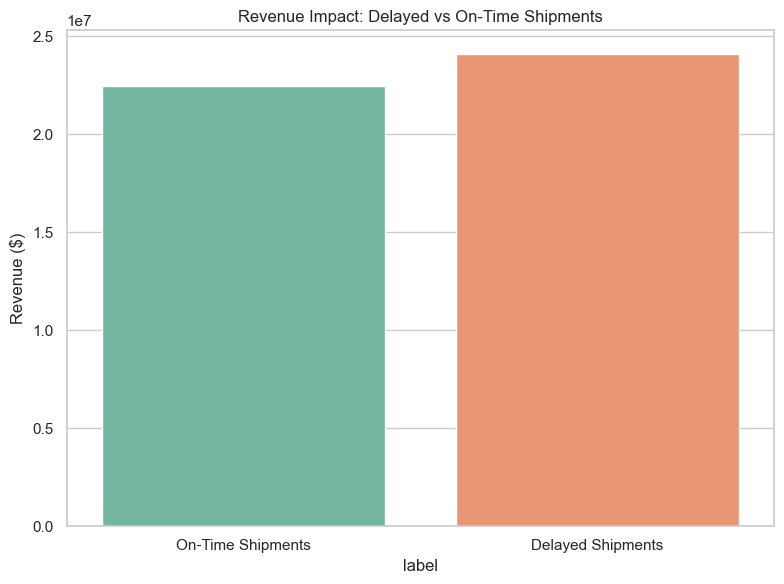

Saved: ..\visuals\charts_from_notebook\revenue_delay_impact.png


,is_delayed,order_value,label
0,False,22474980.88,On-Time Shipments
1,True,24094649.31,Delayed Shipments


In [6]:
# Cell 6: Revenue impacted by delayed shipments

merged_df = orders_df.merge(
    shipments_df[["order_id", "is_delayed"]],
    on="order_id",
    how="left"
)

rev_impact = (
    merged_df.groupby("is_delayed")["order_value"]
    .sum()
    .reset_index()
)

rev_impact["label"] = rev_impact["is_delayed"].map({True: "Delayed Shipments", False: "On-Time Shipments"})

plt.figure(figsize=(8, 6))
sns.barplot(data=rev_impact, x="label", y="order_value", palette="Set2")
plt.title("Revenue Impact: Delayed vs On-Time Shipments")
plt.ylabel("Revenue ($)")
plt.tight_layout()

file_path = OUTPUT_DIR / "revenue_delay_impact.png"
plt.savefig(file_path, dpi=300)
plt.show()

print(f"Saved: {file_path}")
rev_impact


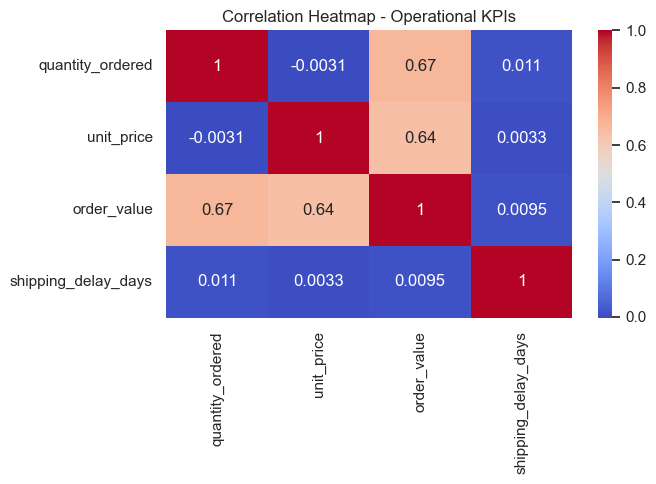

Saved: ..\visuals\charts_from_notebook\kpi_correlation_heatmap.png


,quantity_ordered,unit_price,order_value,shipping_delay_days
quantity_ordered,1.000000,-0.003149,0.670827,0.011293
unit_price,-0.003149,1.000000,0.643393,0.003324
order_value,0.670827,0.643393,1.000000,0.009461
shipping_delay_days,0.011293,0.003324,0.009461,1.000000


In [7]:
# Cell 7: Correlation of key numeric variables

numeric_cols = [
    "quantity_ordered",
    "unit_price",
    "order_value",
    "shipping_delay_days"
]

corr_df = orders_df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Operational KPIs")
plt.tight_layout()

file_path = OUTPUT_DIR / "kpi_correlation_heatmap.png"
plt.savefig(file_path, dpi=300)
plt.show()

print(f"Saved: {file_path}")
corr_df


C:\Users\Charan\AppData\Local\Temp\ipykernel_23076\953289606.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


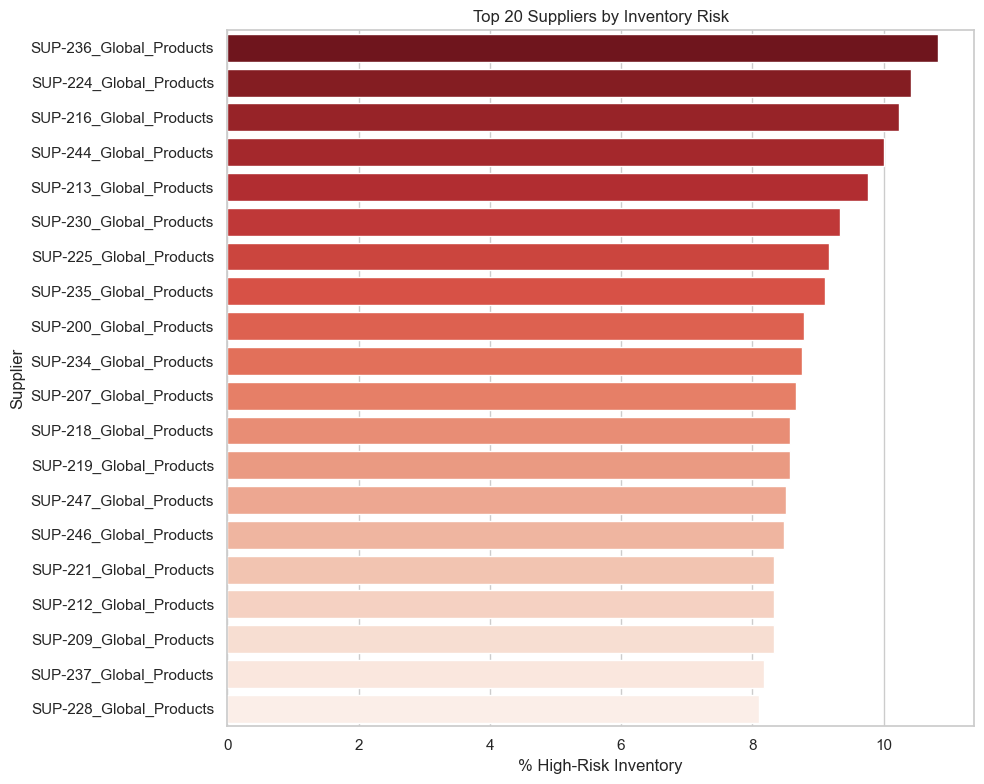

Saved: ..\visuals\charts_from_notebook\supplier_inventory_risk_top20.png


,supplier_id,pct_high_risk_inventory,supplier_name
36,SUP-236,10.833333,SUP-236_Global_Products
24,SUP-224,10.416667,SUP-224_Global_Products
16,SUP-216,10.238095,SUP-216_Global_Products
44,SUP-244,10.000000,SUP-244_Global_Products
13,SUP-213,9.761905,SUP-213_Global_Products
30,SUP-230,9.333333,SUP-230_Global_Products
25,SUP-225,9.166667,SUP-225_Global_Products
35,SUP-235,9.111111,SUP-235_Global_Products
0,SUP-200,8.787879,SUP-200_Global_Products
34,SUP-234,8.750000,SUP-234_Global_Products


In [8]:
# Cell 8: Supplier-level inventory risk

risk_df = (
    inventory_df
    .groupby("supplier_id")["inventory_status"]
    .apply(lambda x: (x.isin(['Critical', 'Out-of-Stock']).mean() * 100))
    .reset_index()
    .rename(columns={"inventory_status": "pct_high_risk_inventory"})
)

risk_df = risk_df.merge(
    suppliers_df[["supplier_id", "supplier_name"]],
    on="supplier_id",
    how="left"
).sort_values("pct_high_risk_inventory", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=risk_df,
    x="pct_high_risk_inventory",
    y="supplier_name",
    palette="Reds_r"
)
plt.xlabel("% High-Risk Inventory")
plt.ylabel("Supplier")
plt.title("Top 20 Suppliers by Inventory Risk")
plt.tight_layout()

file_path = OUTPUT_DIR / "supplier_inventory_risk_top20.png"
plt.savefig(file_path, dpi=300)
plt.show()

print(f"Saved: {file_path}")
risk_df


In [9]:
# Cell 9: Summary metrics to copy into README / video

print("=== KPI SUMMARY ===")
print(f"OTIF Rate: {otif:.2f}%")
print(f"Shipment Delay %: {shipment_delay_pct:.2f}%")
print(f"Avg Shipping Delay: {avg_shipping_delay:.2f} days")
print(f"Inventory Risk (Critical/Stockout): {inventory_low_pct:.2f}%")
print(f"Total Revenue: ${total_revenue:,.2f}")


=== KPI SUMMARY ===
OTIF Rate: 38.07%
Shipment Delay %: 51.99%
Avg Shipping Delay: 0.50 days
Inventory Risk (Critical/Stockout): 7.65%
Total Revenue: $58,131,313.02
